# GCAP3226 Week 4 — In-class exercise (5%)

**Individual.** Three tasks + submit (Commit & Push → Moodle GitHub URL).

| Task | Do this |
|------|---------|
| **1** | Percentage change by A&E triage; largest fall / rise; triage 4+5 combined |
| **2** | Grouped bar chart: H1 2025 vs H1 2026 attendances by triage (10 bars) + numbers / percentage change |
| **3** | Short write-up: one supporting point + one gap for the A&E claim |


## Setup

Run the next cell. Data: `week4_ae_triage_h1.csv` (**H1** 2025 vs **H1** 2026 attendances by triage).

**H1** = first half of the year (usually **1 January – 30 June**).

**AI:** `Cmd+I` / `Ctrl+I` on a code cell → implement the comment prompt → **Keep**. Interpretations in your own words.

In [23]:
# Setup — run first
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_FILE = "week4_ae_triage_h1.csv"
path = Path(DATA_FILE) if Path(DATA_FILE).is_file() else Path.cwd() / DATA_FILE
df = pd.read_csv(path)
print("Using:", path.resolve())
df

Using: /workspaces/GCAP3226_week4/week4_ae_triage_h1.csv


,triage,triage_name,attend_h1_2025,attend_h1_2026
0,1,Critical,13848,14541
1,2,Emergency,28554,29981
2,3,Urgent,400428,411994
3,4,Semi-urgent,489032,441974
4,5,Non-urgent,18448,14758


## Task 1 — Percentage change

**Purpose:** Measure how A&E attendances changed from H1 2025 to H1 2026 for each triage group, so you can see which groups rose or fell before judging the A&E claim in Task 3.

1. Add a column `pct_change` = `(attend_h1_2026 - attend_h1_2025) / attend_h1_2025 * 100`.
2. Show the table.
3. Print the triage with the **largest fall** and the **largest rise**.
4. Compute the percentage change for triage **4+5 combined** (sum attendances first, then apply the same formula).

Then, in the next cell, write **1–2 sentences** answering:
- Did triage **1–2** (Critical / Emergency) mainly **rise or fall**?
- Did triage **4–5** (Semi-urgent / Non-urgent) mainly **rise or fall**?
- In one short phrase: what does that pattern look like for the A&E claim (lower-urgency down; critical/emergency protected)?


In [24]:
# Task 1
#
# Input: df (triage, triage_name, attend_h1_2025, attend_h1_2026)
# Process: Write Python code to add pct_change, display the table,
#          print largest fall and largest rise; also 4+5 combined percentage change
# Output: table + printed fall/rise + 4+5 combined
#
# YOUR CODE BELOW

df["pct_change"] = (df["attend_h1_2026"] - df["attend_h1_2025"]) / df["attend_h1_2025"] * 100
display(df.assign(pct_change=df["pct_change"].map(lambda value: f"{value:.2f}%")))

largest_fall = df.loc[df["pct_change"].idxmin()]
largest_rise = df.loc[df["pct_change"].idxmax()]
print(f"Largest fall: {largest_fall['triage_name']} ({largest_fall['pct_change']:.2f}%)")
print(f"Largest rise: {largest_rise['triage_name']} ({largest_rise['pct_change']:.2f}%)")

triage_4_5 = df[df["triage"].isin([4, 5])]
combined_change = (triage_4_5["attend_h1_2026"].sum() - triage_4_5["attend_h1_2025"].sum()) / triage_4_5["attend_h1_2025"].sum() * 100
print(f"Triage 4+5 combined percentage change: {combined_change:.2f}%")

,triage,triage_name,attend_h1_2025,attend_h1_2026,pct_change
0,1,Critical,13848,14541,5.00%
1,2,Emergency,28554,29981,5.00%
2,3,Urgent,400428,411994,2.89%
3,4,Semi-urgent,489032,441974,-9.62%
4,5,Non-urgent,18448,14758,-20.00%


Largest fall: Non-urgent (-20.00%)
Largest rise: Critical (5.00%)
Triage 4+5 combined percentage change: -10.00%


In [25]:
# Task 1 note
task1_note = "Triage 1–2 attendances mainly rose, while triage 4–5 mainly fell. This pattern is consistent with lower-urgency attendances falling while critical/emergency attendances did not fall."
print(task1_note)

Triage 1–2 attendances mainly rose, while triage 4–5 mainly fell. This pattern is consistent with lower-urgency attendances falling while critical/emergency attendances did not fall.


## Task 2 — Visualization

**Purpose:** Turn the Task 1 table into a **grouped bar chart** that compares H1 2025 and H1 2026 attendances for each triage (5 groups, 2 bars each → 10 bars), and makes the **numbers** and **percentage change** easy to see.

In the next code cell, write your own IPO comment prompt, then use Inline Chat to implement it. Interpretations stay in your own words.


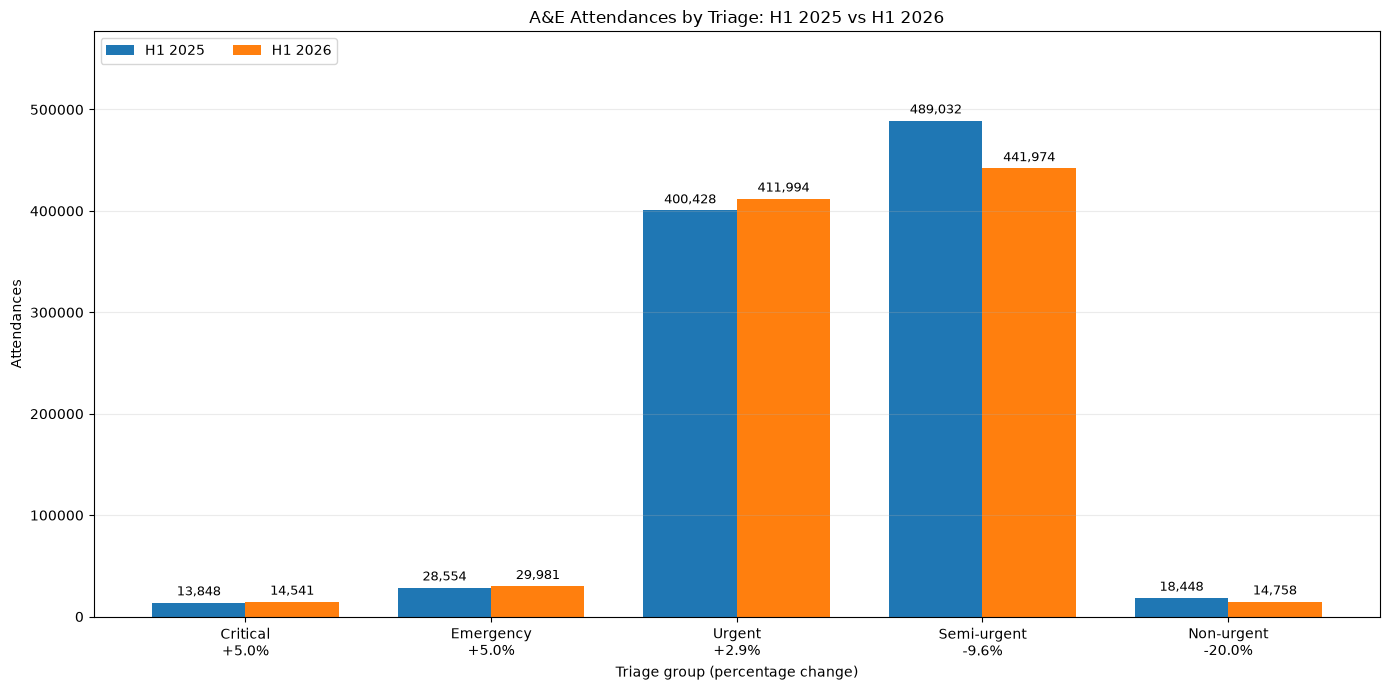

In [26]:
# Task 2
#
# Input: df with triage_name, attendance columns, and pct_change
# Process: Draw two bars per triage and label attendance and percentage change.
# Output: Grouped bar chart

x = range(len(df))
width = 0.38
fig, ax = plt.subplots(figsize=(14, 7))

bars_2025 = ax.bar([i - width / 2 for i in x], df["attend_h1_2025"], width, label="H1 2025")
bars_2026 = ax.bar([i + width / 2 for i in x], df["attend_h1_2026"], width, label="H1 2026")

ax.bar_label(bars_2025, labels=[f"{value:,.0f}" for value in df["attend_h1_2025"]], padding=3, fontsize=9)
ax.bar_label(bars_2026, labels=[f"{value:,.0f}" for value in df["attend_h1_2026"]], padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f"{row.triage_name}\n{row.pct_change:+.1f}%" for row in df.itertuples()])
ax.set_xlabel("Triage group (percentage change)")
ax.set_ylabel("Attendances")
ax.set_title("A&E Attendances by Triage: H1 2025 vs H1 2026")
ax.set_ylim(0, df[["attend_h1_2025", "attend_h1_2026"]].to_numpy().max() * 1.18)
ax.legend(ncols=2, loc="upper left")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## Task 3 — Write-up

**Claim:** After fee reform, A&E improved — lower-urgency attendances fell; critical/emergency care stayed protected; urgent care became more efficient.

You may also cite: triage III within 30 min **81.4 → 88.5** (percentage); mean wait **23 → 20** min.

**3a** — Write **one supporting point** (cite a number) and **one gap** in the evidence.

**3b** — 2–4 sentences: how well is the claim supported by the published evidence (your table / chart, and any figures cited above)?


In [27]:
# Task 3
task3a = """
3a SUPPORT (1 point, cite a number):
Triage 4 and 5 attendances fell from 507,480 in H1 2025 to 456,732 in H1 2026, a 10.00% decrease.

3a GAP (1 point):
There is no comparison group, so we cannot tell if fee reform caused the fall.
"""

task3b = """
3b:
The evidence supports the claim: lower-urgency triage 4–5 attendances declined, while Critical and Emergency attendances did not decline. The proportion of triage III patients seen within 30 minutes rose from 81.4% to 88.5%, and mean waiting time decreased from 23 to 20 minutes. These changes are associated with the fee reform, but the evidence does not establish that the reform caused the improvements.
"""

print(task3a)
print("---")
print(task3b)



3a SUPPORT (1 point, cite a number):
Triage 4 and 5 attendances fell from 507,480 in H1 2025 to 456,732 in H1 2026, a 10.00% decrease.

3a GAP (1 point):
There is no comparison group, so we cannot tell if fee reform caused the fall.

---

3b:
The evidence supports the claim: lower-urgency triage 4–5 attendances declined, while Critical and Emergency attendances did not decline. The proportion of triage III patients seen within 30 minutes rose from 81.4% to 88.5%, and mean waiting time decreased from 23 to 20 minutes. These changes are associated with the fee reform, but the evidence does not establish that the reform caused the improvements.



## Submit

1. Save → Source Control → **Commit & Push**  
2. Moodle: paste your **GitHub URL**
